# Data exploration — SUR 2025/2026

Goal: build a complete picture of what we're working with **before** writing a single line of model code. The assignment explicitly rewards good validation strategy and generalization — both depend on understanding the data's structure (identities, sessions, prompts, modalities).

Filename schema: `<identity>_<session>_<prompt>_i<inst>_<take>.{png,wav}`
- `identity` — e.g. `m431`, `f401` (`m`/`f` = reported gender, numeric id)
- `session` — recording sitting (shared lighting / mic / background)
- `prompt` — utterance / pose token (e.g. `p01`, `r08`, `f16`)
- `i<inst>_<take>` — instance / take within session

Run with `uv run jupyter lab` (or execute cell-by-cell from VS Code using the uv-managed kernel).

In [16]:
from pathlib import Path
import re
import wave
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_rows", 60)

DATA = Path("../data").resolve()
SPLITS = {
    "target_train":     {"split": "train", "label": 1},
    "target_dev":       {"split": "dev",   "label": 1},
    "non_target_train": {"split": "train", "label": 0},
    "non_target_dev":   {"split": "dev",   "label": 0},
}
DATA, sorted(p.name for p in DATA.iterdir())

(PosixPath('/Users/ramsay/school/sur/project/data'),
 ['SUR_projekt2025-2026.txt',
  'non_target_dev',
  'non_target_train',
  'target_dev',
  'target_train'])

## 1. Build a manifest DataFrame

One row per file. Parse the filename schema into columns we can group on. Keeping images and audio as separate rows (rather than pairing up-front) lets us sanity-check that every PNG has a matching WAV.

In [17]:
NAME_RE = re.compile(r"^(?P<identity>[fm]\d+)_(?P<session>\d+)_(?P<prompt>[a-z]\d+)_i(?P<inst>\d+)_(?P<take>\d+)$")

rows = []
for folder, meta in SPLITS.items():
    for p in sorted((DATA / folder).iterdir()):
        if p.suffix.lower() not in {".png", ".wav"}:
            continue
        m = NAME_RE.match(p.stem)
        if not m:
            raise ValueError(f"unexpected filename: {p.name}")
        rows.append({
            **m.groupdict(),
            "modality": "image" if p.suffix.lower() == ".png" else "audio",
            "folder": folder,
            "split": meta["split"],
            "label": meta["label"],
            "path": str(p),
            "stem": p.stem,
            "bytes": p.stat().st_size,
        })

df = pd.DataFrame(rows)
df["session_id"] = df["identity"] + "_" + df["session"]
df.head()

,identity,session,prompt,inst,take,modality,folder,split,label,path,stem,bytes,session_id
0,m431,01,p01,0,0,image,target_train,train,1,/Users/ramsay/school/sur/project/data/target_t...,m431_01_p01_i0_0,10433,m431_01
1,m431,01,p01,0,0,audio,target_train,train,1,/Users/ramsay/school/sur/project/data/target_t...,m431_01_p01_i0_0,222594,m431_01
2,m431,01,p02,0,0,image,target_train,train,1,/Users/ramsay/school/sur/project/data/target_t...,m431_01_p02_i0_0,9805,m431_01
3,m431,01,p02,0,0,audio,target_train,train,1,/Users/ramsay/school/sur/project/data/target_t...,m431_01_p02_i0_0,311340,m431_01
4,m431,01,p03,0,0,image,target_train,train,1,/Users/ramsay/school/sur/project/data/target_t...,m431_01_p03_i0_0,9966,m431_01


In [18]:
print(f"Total files: {len(df)}")
print(f"Unique (identity, session) combos: {df['session_id'].nunique()}")
print(f"Unique identities: {df['identity'].nunique()}")
print(f"Unique prompts: {df['prompt'].nunique()}")
df.groupby(["split", "label", "modality"]).size().unstack(fill_value=0)

Total files: 444
Unique (identity, session) combos: 99
Unique identities: 20
Unique prompts: 11


modality     audio  image
split label              
dev   0         60     60
      1         10     10
train 0        132    132
      1         20     20

## 2. Pairing: does every image have a matching audio?

If yes, every sample can be used for multimodal fusion. If not, some rows will be modality-only.

In [19]:
pairs = df.pivot_table(index=["folder", "stem"], columns="modality", values="path", aggfunc="first")
print(f"Samples missing audio: {pairs['audio'].isna().sum()}")
print(f"Samples missing image: {pairs['image'].isna().sum()}")
print(f"Complete pairs: {pairs.dropna().shape[0]}")

Samples missing audio: 0
Samples missing image: 0
Complete pairs: 222


## 3. Identity and session structure

This is the single most important table in the notebook — it dictates how to design cross-validation.

- **Target**: few sessions of one person. Split *by session* so the model sees new lighting / mic at val time.
- **Non-target**: many people, few sessions each. Split *by identity* so val contains unseen strangers.

In [20]:
images = df[df.modality == "image"]  # drop audio dupes for per-sample counts
summary = (
    images.groupby(["label", "split", "identity"])
    .agg(sessions=("session", "nunique"), samples=("stem", "count"))
    .reset_index()
    .sort_values(["label", "split", "identity"], ascending=[False, True, True])
)
summary

,label,split,identity,sessions,samples
19,1,dev,m431,1,10
20,1,train,m431,2,20
0,0,dev,f407,5,10
1,0,dev,f408,5,10
2,0,dev,f409,5,10
3,0,dev,m423,5,10
4,0,dev,m424,5,10
5,0,dev,m425,5,10
6,0,train,f401,5,10
7,0,train,f402,5,10


In [21]:
nt_train = set(images.query("label == 0 and split == 'train'")["identity"])
nt_dev   = set(images.query("label == 0 and split == 'dev'")["identity"])
print(f"non_target train identities ({len(nt_train)}): {sorted(nt_train)}")
print(f"non_target dev identities   ({len(nt_dev)}): {sorted(nt_dev)}")
print(f"overlap: {sorted(nt_train & nt_dev) or 'none — identity-disjoint'}")

t_train = images.query("label == 1 and split == 'train'")
t_dev   = images.query("label == 1 and split == 'dev'")
print(f"\ntarget identity: {sorted(set(images.query('label == 1').identity))}")
print(f"  train sessions: {sorted(set(t_train.session))}")
print(f"  dev sessions:   {sorted(set(t_dev.session))}")
print(f"  session overlap: {sorted(set(t_train.session) & set(t_dev.session)) or 'none — session-disjoint'}")

non_target train identities (13): ['f401', 'f402', 'f403', 'f404', 'f405', 'f406', 'm414', 'm416', 'm417', 'm419', 'm420', 'm421', 'm422']
non_target dev identities   (6): ['f407', 'f408', 'f409', 'm423', 'm424', 'm425']
overlap: none — identity-disjoint

target identity: ['m431']
  train sessions: ['01', '02']
  dev sessions:   ['03']
  session overlap: none — session-disjoint


If the output confirms both disjointness checks, the organizers' split already respects the right principle — we should keep following it when we re-carve folds for CV on the combined train+dev pool.

In [22]:
# Prompt distribution — do target and non-target share prompts?
prompt_tab = images.pivot_table(index="prompt", columns=["label", "split"], values="stem", aggfunc="count", fill_value=0)
prompt_tab

label    0         1      
split  dev train dev train
prompt                    
f16     30    66   0     0
p01      0     0   1     2
p02      0     0   1     2
p03      0     0   1     2
p04      0     0   1     2
p05      0     0   1     2
r06      0     0   1     2
r07      0     0   1     2
r08     30    66   1     2
r09      0     0   1     2
r10      0     0   1     2

If target uses prompts non-targets never use (or vice-versa), a naive audio model can cheat by recognizing the utterance rather than the speaker. Keep this in mind when choosing features.

/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_84760/3580781318.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["non-target (0)", "target (1)"])


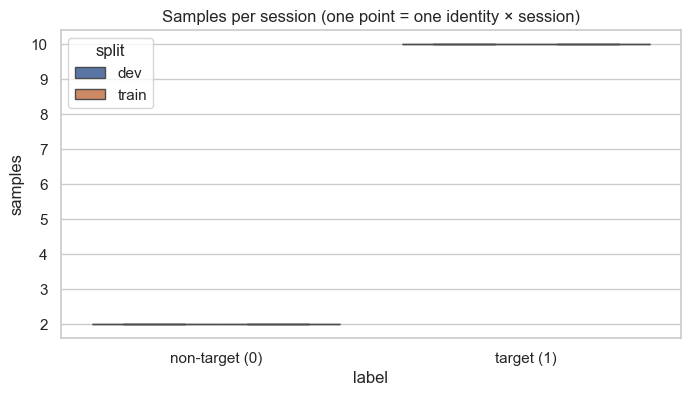

In [23]:
per_session = (
    images.groupby(["label", "split", "session_id"]).size()
    .rename("samples").reset_index()
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=per_session, x="label", y="samples", hue="split", ax=ax)
ax.set_title("Samples per session (one point = one identity × session)")
ax.set_xticklabels(["non-target (0)", "target (1)"])
plt.show()

## 4. Image analysis

Resolution, colour mode, pixel statistics, plus a visual grid so we see what the detector has to work with.

In [24]:
def image_meta(path: str) -> dict:
    with Image.open(path) as im:
        arr = np.asarray(im)
        return {
            "width": im.width,
            "height": im.height,
            "mode": im.mode,
            "mean": float(arr.mean()),
            "std": float(arr.std()),
            "min": int(arr.min()),
            "max": int(arr.max()),
            "channels": arr.shape[2] if arr.ndim == 3 else 1,
        }

img_df = images.reset_index(drop=True).copy()
img_meta_df = pd.DataFrame([image_meta(p) for p in img_df.path])
img_df = pd.concat([img_df, img_meta_df], axis=1)
img_df[["width", "height", "mode", "channels"]].drop_duplicates()

,width,height,mode,channels
0,80,80,RGB,3


In [25]:
img_df.groupby(["label", "split"])[["mean", "std"]].agg(["mean", "min", "max"]).round(2)

mean                   std              
               mean    min     max   mean    min    max
label split                                            
0     dev    114.36  82.95  140.43  52.31  29.93  74.42
      train  113.01  61.27  170.13  53.45  32.22  74.47
1     dev     83.59  74.61   97.67  43.36  33.62  54.04
      train  106.96  99.59  113.27  45.08  36.75  53.90

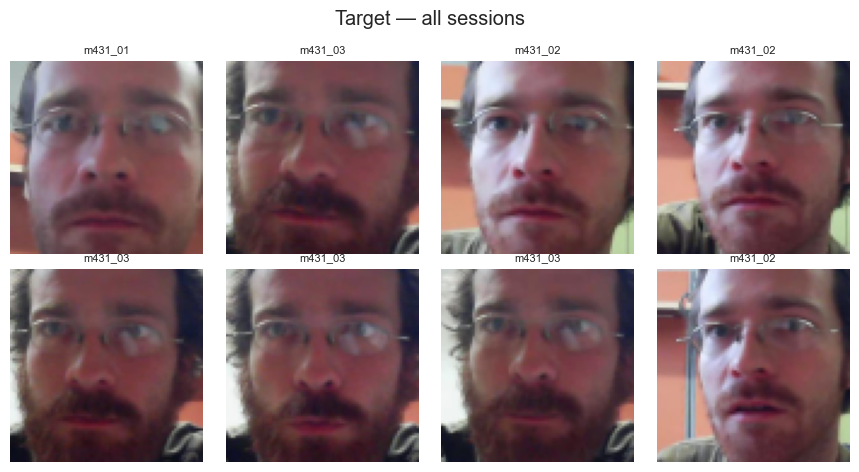

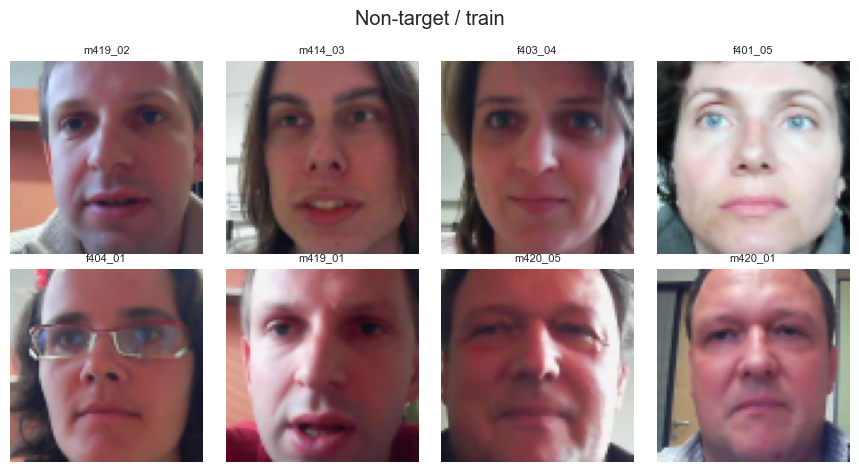

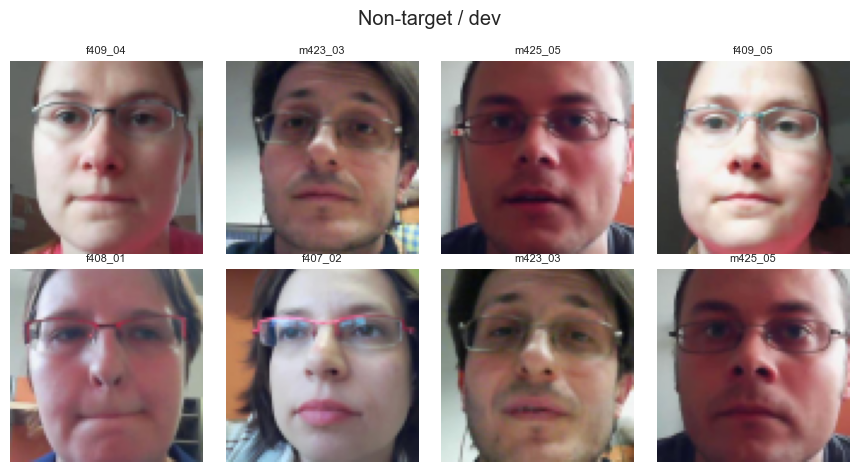

In [26]:
def show_grid(sub: pd.DataFrame, title: str, n: int = 8):
    sub = sub.sample(min(n, len(sub)), random_state=0)
    cols = 4
    rows = int(np.ceil(len(sub) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.4))
    flat = np.atleast_1d(axes).ravel()
    for ax, (_, r) in zip(flat, sub.iterrows()):
        ax.imshow(Image.open(r.path))
        ax.set_title(f"{r.identity}_{r.session}", fontsize=8)
        ax.axis("off")
    for ax in flat[len(sub):]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_grid(img_df.query("label == 1"), "Target — all sessions")
show_grid(img_df.query("label == 0 and split == 'train'"), "Non-target / train")
show_grid(img_df.query("label == 0 and split == 'dev'"), "Non-target / dev")

## 5. Audio analysis

Uses only the stdlib `wave` module (no librosa / scipy in the env). Reads the header for sample rate / duration / channels / bit depth, then computes amplitude statistics from the raw PCM.

In [27]:
def audio_meta(path: str) -> dict:
    with wave.open(path, "rb") as w:
        sr = w.getframerate()
        n = w.getnframes()
        ch = w.getnchannels()
        sw = w.getsampwidth()
        raw = w.readframes(n)
    dtype = {1: np.int8, 2: np.int16, 4: np.int32}[sw]
    x = np.frombuffer(raw, dtype=dtype).astype(np.float32)
    if ch > 1:
        x = x.reshape(-1, ch).mean(axis=1)
    peak = float(np.iinfo(dtype).max)
    xn = x / peak
    return {
        "sr": sr,
        "duration_s": n / sr,
        "channels": ch,
        "bit_depth": sw * 8,
        "rms": float(np.sqrt((xn ** 2).mean())),
        "peak": float(np.abs(xn).max()),
        "zero_crossing_rate": float(np.mean(np.abs(np.diff(np.sign(xn))) > 0)),
    }

audio = df[df.modality == "audio"].reset_index(drop=True).copy()
audio_meta_df = pd.DataFrame([audio_meta(p) for p in audio.path])
audio_df = pd.concat([audio, audio_meta_df], axis=1)
audio_df[["sr", "channels", "bit_depth"]].drop_duplicates()

,sr,channels,bit_depth
0,16000,1,16


In [28]:
audio_df.groupby(["label", "split"])[["duration_s", "rms", "peak", "zero_crossing_rate"]].agg(["mean", "min", "max"]).round(3)

duration_s                   rms                 peak         \
                  mean    min     max   mean    min    max   mean    min   
label split                                                                
0     dev       14.091  6.507  41.963  0.015  0.007  0.026  0.155  0.088   
      train     15.349  6.037  44.459  0.016  0.006  0.029  0.165  0.051   
1     dev        7.913  6.293  10.539  0.015  0.014  0.017  0.167  0.124   
      train      9.073  6.869  12.373  0.019  0.014  0.025  0.160  0.108   

                   zero_crossing_rate                
               max               mean    min    max  
label split                                          
0     dev    0.293              0.066  0.036  0.123  
      train  0.362              0.061  0.036  0.100  
1     dev    0.260              0.059  0.050  0.068  
      train  0.255              0.041  0.032  0.055

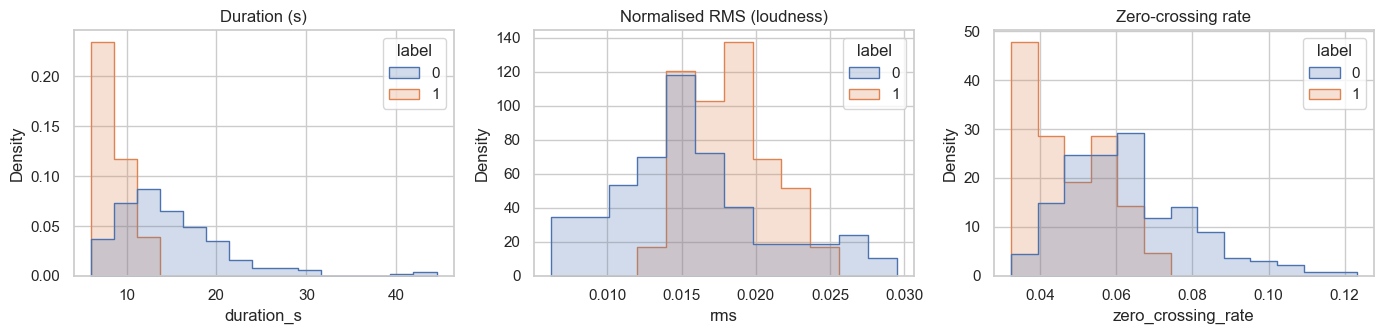

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
sns.histplot(audio_df, x="duration_s", hue="label", element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Duration (s)")
sns.histplot(audio_df, x="rms", hue="label", element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Normalised RMS (loudness)")
sns.histplot(audio_df, x="zero_crossing_rate", hue="label", element="step", stat="density", common_norm=False, ax=axes[2])
axes[2].set_title("Zero-crossing rate")
plt.tight_layout()
plt.show()

Watch out for systematic differences (e.g. target recordings all longer / louder than non-target). If such leakage exists, a dumb loudness detector will "work" on dev but break on eval. We want features that are invariant to these nuisance factors.

## 6. Cross-validation sketch

Principles:
- Never put two samples from the same `session_id` on opposite sides of a fold.
- Never put the same non-target identity on opposite sides (identity-level leakage on the negative side is as bad as session leakage on the positive side).

The function below returns fold assignments we can reuse during training. Pure numpy — no sklearn dependency.

In [30]:
def suggest_folds(images: pd.DataFrame, n_splits: int = 5, seed: int = 0) -> pd.DataFrame:
    """Group target rows by session_id, non-target rows by identity, then round-robin into folds."""
    rng = np.random.default_rng(seed)
    pool = images.copy()
    pool["group"] = np.where(pool.label == 1, pool.session_id, pool.identity)
    fold_of: dict[str, int] = {}
    for lbl, sub in pool[["label", "group"]].drop_duplicates().groupby("label"):
        g = sub["group"].to_numpy()
        rng.shuffle(g)
        for i, name in enumerate(g):
            fold_of[name] = i % n_splits
    pool["fold"] = pool["group"].map(fold_of)
    return pool[["stem", "label", "group", "fold"]]

folds = suggest_folds(images)
folds.groupby(["fold", "label"]).size().unstack(fill_value=0)

label,0,1
fold,,
0,40,10
1,40,10
2,40,10
3,42,0
4,30,0


## 7. Takeaways

Fill in once the cells have run — record actual numbers here so we don't have to re-read the notebook later.

- Target identity: `?`
- Target sessions available (train+dev): `?`
- Non-target identities (train / dev): `? / ?`, overlap: `?`
- Samples per session (target vs non-target, median): `? / ?`
- Image resolution / mode: `?`
- Audio sample rate / bit depth / channels: `?`
- Suspect leakage signals (loudness, duration, prompt set): `?`
- CV plan: 5-fold, session-grouped on target, identity-grouped on non-target.